Step 1: Negative data generation

In [ ]:
import pandas as pd
import os
import re
from rdkit import Chem
from rdkit.Chem import MACCSkeys
from rdkit.DataStructs import FingerprintSimilarity
import random
from tqdm import tqdm

random.seed(42)

def contains_ion(smiles):
    return '+' in smiles or '-' in smiles


def get_net_charge(smiles):
    """Calculate net charge of a molecule from its SMILES string"""
    # Count all '+' not followed by '-' and not preceded by '-'
    positive_charges = len(re.findall(r'(?<!-)\+(?!-)', smiles))
    # Count all '-' not followed by '+' and not preceded by '+'
    negative_charges = len(re.findall(r'(?<!\+)-(?!\+)', smiles))
    return positive_charges - negative_charges

# 定义一个函数，用于检查是否为正离子
def is_positive_ion(smiles):
    return get_net_charge(smiles) > 0

# 定义一个函数，用于检查是否为负离子
def is_negative_ion(smiles):
    return get_net_charge(smiles) < 0

# 定义一个函数，用于准备离子列表
def prepare_ion_lists(df):
    """Prepare separate lists of positive and negative ions"""
    positive_ions = set()
    negative_ions = set()

    # First collect all unique ions from both columns
    for _, row in df.iterrows():
        smi1, smi2 = row['coformer1'], row['coformer2']
        if is_positive_ion(smi1):
            positive_ions.add(smi1)
        elif is_negative_ion(smi1):
            negative_ions.add(smi1)

        if is_positive_ion(smi2):
            positive_ions.add(smi2)
        elif is_negative_ion(smi2):
            negative_ions.add(smi2)

    return list(positive_ions), list(negative_ions)

# 定义一个函数，用于获取合作伙伴
def get_partners(smiles, df):
    """Get all coformers that appear with this smiles in the dataset"""
    partners = set()
    # Check both columns for the smiles
    partners.update(df[df['coformer1'] == smiles]['coformer2'].tolist())
    partners.update(df[df['coformer2'] == smiles]['coformer1'].tolist())
    return partners

def calculate_tanimoto_similarity(fp1, fp2):
    return FingerprintSimilarity(fp1, fp2)

# 定义生成负样本的函数
def generate_negative_samples(df, threshold=0.5, num_samples=2974, max_attempts=20):
    negative_samples = []

    # Prepare ion lists
    positive_ions, negative_ions = prepare_ion_lists(df)
    print(f"Found {len(positive_ions)} positive ions and {len(negative_ions)} negative ions")

    # Create dictionaries to store fingerprints for faster access
    fps_cache = {}

    def get_fp(smiles):
        if smiles not in fps_cache:
            mol = Chem.MolFromSmiles(smiles)
            fps_cache[smiles] = MACCSkeys.GenMACCSKeys(mol) if mol else None
        return fps_cache[smiles]

    # Create progress bar
    pbar = tqdm(total=num_samples, desc="Generating negative samples")

    while len(negative_samples) < num_samples:
        # Randomly select a starting ion (either positive or negative)
        if random.random() < 0.5 and positive_ions:
            # Start with positive ion
            molA_smiles = random.choice(positive_ions)
            molA_charge = 'positive'
            candidate_pool = negative_ions.copy()
        elif negative_ions:
            # Start with negative ion
            molA_smiles = random.choice(negative_ions)
            molA_charge = 'negative'
            candidate_pool = positive_ions.copy()
        else:
            # No ions left to choose from
            break

        try:
            # Get all partners of molA in original dataset
            molA_partners = get_partners(molA_smiles, df)

            # Get fingerprints for molA and its partners
            molA_fp = get_fp(molA_smiles)
            if molA_fp is None:
                continue

            partner_fps = []
            for partner in molA_partners:
                fp = get_fp(partner)
                if fp is not None:
                    partner_fps.append(fp)

            # Try to find a suitable candidate
            attempts = 0
            found = False

            while attempts < max_attempts and candidate_pool:
                # Randomly select a candidate
                molC_smiles = random.choice(candidate_pool)
                candidate_pool.remove(molC_smiles)  # Don't try this one again
                attempts += 1

                # Check charge compatibility
                molC_charge = 'positive' if is_positive_ion(molC_smiles) else 'negative'
                if not ((molA_charge == 'positive' and molC_charge == 'negative') or
                        (molA_charge == 'negative' and molC_charge == 'positive')):
                    continue

                # Get fingerprint for candidate
                molC_fp = get_fp(molC_smiles)
                if molC_fp is None:
                    continue

                # Check similarity with all partners
                is_similar = any(FingerprintSimilarity(molC_fp, partner_fp) >= threshold
                                 for partner_fp in partner_fps)

                if not is_similar:
                    negative_samples.append((molA_smiles, molC_smiles))
                    pbar.update(1)
                    found = True
                    break

            if not found and attempts >= max_attempts:
                print(f"Failed to find suitable partner for {molA_smiles} after {max_attempts} attempts")

        except Exception as e:
            print(f"Error processing {molA_smiles}: {e}")

    pbar.close()
    return negative_samples

def generate_neutral_negative_samples(df, threshold=0.5, num_samples=2974):
    negative_samples = []
    fps_cache = {}

    def get_fp(smiles):
        if smiles not in fps_cache:
            mol = Chem.MolFromSmiles(smiles)
            fps_cache[smiles] = MACCSkeys.GenMACCSKeys(mol) if mol else None
        return fps_cache[smiles]

    pbar = tqdm(total=num_samples, desc="Generating neutral negative samples")
    while len(negative_samples) < num_samples:
        random_row = df.sample(n=1)
        molA_smiles = random_row.iloc[0]['coformer1']
        molA_name = random_row.iloc[0].get('name', 'Unknown')

        try:
            molA_rows = df[(df['coformer1'] == molA_smiles) | (df['coformer2'] == molA_smiles)]
            other_smiles_list = [row['coformer2'] if row['coformer1'] == molA_smiles else row['coformer1'] for index, row in molA_rows.iterrows()]

            while True:
                random_row = df.sample(n=1)
                molC_smiles = random_row.iloc[0]['coformer1'] if random_row.iloc[0]['coformer1'] != molA_smiles else random_row.iloc[0]['coformer2']

                molA_fp = get_fp(molA_smiles)
                molC_fp = get_fp(molC_smiles)

                is_similar = any(FingerprintSimilarity(molC_fp, get_fp(other_smiles)) >= threshold for other_smiles in other_smiles_list)

                if not is_similar:
                    negative_samples.append((molA_smiles, molC_smiles))
                    pbar.update(1)
                    break

        except Exception as e:
            print(f"Error processing {molA_name}: {e}")

    pbar.close()
    return negative_samples

    return negative_samples, error_log
threshold = 0.4


In [ ]:
# 读取输入的CSV文件
names = ['lowT','mediumT','highT']

for name in names:
    
    input_file_path = f'./temperature_analysis/temperature_{name}.csv'
    df = pd.read_csv(input_file_path)
    # 将数据分成中性部分和离子部分
    neutral_df = df[~df['SMILES'].apply(contains_ion)]
    ionic_df = df[df['SMILES'].apply(contains_ion)]
    # Generate negative samples for neutral and ionic parts
    neutral_negative_samples = generate_neutral_negative_samples(neutral_df,threshold=threshold,num_samples=len(neutral_df))
    ionic_negative_samples = generate_negative_samples(ionic_df,threshold=threshold,num_samples=len(ionic_df))
    
    # Convert negative samples to DataFrames
    neutral_negative_samples_df = pd.DataFrame(neutral_negative_samples, columns=['coformer1', 'coformer2'])
    ionic_negative_samples_df = pd.DataFrame(ionic_negative_samples, columns=['coformer1', 'coformer2'])
    
    # Get the directory and base name of the input file
    input_dir = os.path.dirname(input_file_path)
    input_base_name = os.path.basename(input_file_path).split('.')[0]
    
    # Save negative samples to CSV files
    neutral_output_file_path = os.path.join(input_dir, f"{input_base_name}_negative_samples_neutral.csv")
    ionic_output_file_path = os.path.join(input_dir, f"{input_base_name}_negative_samples_ionic.csv")
    neutral_negative_samples_df.to_csv(neutral_output_file_path, index=False)
    ionic_negative_samples_df.to_csv(ionic_output_file_path, index=False)
    
    print(f"Negative samples saved to {neutral_output_file_path}")
    print(f"Negative samples saved to {ionic_output_file_path}")

In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import MACCSkeys
import os
names = ['highT', 'mediumT', 'lowT']
for name in names:
    # 定义文件路径
    input_folder = f'./temperature_analysis/{name}'
    file_names = [f'temperature_{name}.csv', f'temperature_{name}_negative_samples_ionic.csv', f'temperature_{name}_negative_samples_neutral.csv']
    
    # 初始化一个空的列表来存储所有数据
    all_data = []
    
    # 初始化negative_label计数器
    negative_counter = 0
    
    # 遍历文件
    for i, file_name in enumerate(file_names):
        file_path = os.path.join(input_folder, file_name)
        df = pd.read_csv(file_path)
        
        # 提取coformer1和coformer2
        for _, row in df.iterrows():
            coformer1 = row['coformer1']
            coformer2 = row['coformer2']
            refcode = row.get('Refcode', None)  # 假设文件中包含refcode列
            
            # 生成MACCS键
            mol1 = Chem.MolFromSmiles(coformer1)
            mol2 = Chem.MolFromSmiles(coformer2)
            
            if mol1 is not None and mol2 is not None:
                fp1 = MACCSkeys.GenMACCSKeys(mol1)
                fp2 = MACCSkeys.GenMACCSKeys(mol2)
                
                # 将两个MACCS键相加
                combined_fp = [fp1.GetBit(i) + fp2.GetBit(i) for i in range(fp1.GetNumBits())]
                
                # 生成form
                form = 1 if i == 0 else 0
                
                # 生成negative_label，如果是负样本
                if i > 0 and refcode is None:
                    refcode = f"negative_{negative_counter}"
                    negative_counter += 1
                
                # 将数据添加到列表
                all_data.append([coformer1, coformer2, refcode] + combined_fp + [form])
    
    # 将所有数据转换为DataFrame
    columns = ['coformer1', 'coformer2', 'refcode'] + [f'bit_{i}' for i in range(167)] + ['form']
    result_df = pd.DataFrame(all_data, columns=columns)
    
    # 保存结果到CSV文件
    output_file_path = os.path.join(input_folder, 'training_dataset.csv')
    result_df.to_csv(output_file_path, index=False)
    
    print(f"Training dataset saved to {output_file_path}")

In [ ]:
import pandas as pd
import os
import re
from rdkit import Chem
from rdkit.Chem import MACCSkeys
from rdkit.DataStructs import FingerprintSimilarity
import random
from tqdm import tqdm

random.seed(42)

# 读取输入的CSV文件
df1 =pd.read_csv('./temperature_analysis/lowT/temperature_lowT.csv')
df2 =pd.read_csv('./temperature_analysis/highT/temperature_highT.csv')
df3 =pd.read_csv('./temperature_analysis/mediumT/temperature_mediumT.csv')
df = pd.concat([df1, df2, df3], ignore_index=True)

# 定义一个函数，用于检查SMILES是否包含离子
def contains_ion(smiles):
    return '+' in smiles or '-' in smiles

# 将数据分成中性部分和离子部分
neutral_df = df[~df['SMILES'].apply(contains_ion)]
ionic_df = df[df['SMILES'].apply(contains_ion)]

# 定义一个函数，用于计算净电荷
print(len(neutral_df))
print(len(ionic_df))
def get_net_charge(smiles):
    """Calculate net charge of a molecule from its SMILES string"""
    # Count all '+' not followed by '-' and not preceded by '-'
    positive_charges = len(re.findall(r'(?<!-)\+(?!-)', smiles))
    # Count all '-' not followed by '+' and not preceded by '+'
    negative_charges = len(re.findall(r'(?<!\+)-(?!\+)', smiles))
    return positive_charges - negative_charges

# 定义一个函数，用于检查是否为正离子
def is_positive_ion(smiles):
    return get_net_charge(smiles) > 0

# 定义一个函数，用于检查是否为负离子
def is_negative_ion(smiles):
    return get_net_charge(smiles) < 0

# 定义一个函数，用于准备离子列表
def prepare_ion_lists(df):
    """Prepare separate lists of positive and negative ions"""
    positive_ions = set()
    negative_ions = set()

    # First collect all unique ions from both columns
    for _, row in df.iterrows():
        smi1, smi2 = row['coformer1'], row['coformer2']
        if is_positive_ion(smi1):
            positive_ions.add(smi1)
        elif is_negative_ion(smi1):
            negative_ions.add(smi1)

        if is_positive_ion(smi2):
            positive_ions.add(smi2)
        elif is_negative_ion(smi2):
            negative_ions.add(smi2)

    return list(positive_ions), list(negative_ions)

# 定义一个函数，用于获取合作伙伴
def get_partners(smiles, df):
    """Get all coformers that appear with this smiles in the dataset"""
    partners = set()
    # Check both columns for the smiles
    partners.update(df[df['coformer1'] == smiles]['coformer2'].tolist())
    partners.update(df[df['coformer2'] == smiles]['coformer1'].tolist())
    return partners

def calculate_tanimoto_similarity(fp1, fp2):
    return FingerprintSimilarity(fp1, fp2)

# 定义生成负样本的函数
def generate_negative_samples(df, threshold=0.4, num_samples=2974, max_attempts=20):
    negative_samples = []

    # Prepare ion lists
    positive_ions, negative_ions = prepare_ion_lists(df)
    print(f"Found {len(positive_ions)} positive ions and {len(negative_ions)} negative ions")

    # Create dictionaries to store fingerprints for faster access
    fps_cache = {}

    def get_fp(smiles):
        if smiles not in fps_cache:
            mol = Chem.MolFromSmiles(smiles)
            fps_cache[smiles] = MACCSkeys.GenMACCSKeys(mol) if mol else None
        return fps_cache[smiles]

    # Create progress bar
    pbar = tqdm(total=num_samples, desc="Generating negative samples")

    while len(negative_samples) < num_samples:
        # Randomly select a starting ion (either positive or negative)
        if random.random() < 0.5 and positive_ions:
            # Start with positive ion
            molA_smiles = random.choice(positive_ions)
            molA_charge = 'positive'
            candidate_pool = negative_ions.copy()
        elif negative_ions:
            # Start with negative ion
            molA_smiles = random.choice(negative_ions)
            molA_charge = 'negative'
            candidate_pool = positive_ions.copy()
        else:
            # No ions left to choose from
            break

        try:
            # Get all partners of molA in original dataset
            molA_partners = get_partners(molA_smiles, df)

            # Get fingerprints for molA and its partners
            molA_fp = get_fp(molA_smiles)
            if molA_fp is None:
                continue

            partner_fps = []
            for partner in molA_partners:
                fp = get_fp(partner)
                if fp is not None:
                    partner_fps.append(fp)

            # Try to find a suitable candidate
            attempts = 0
            found = False

            while attempts < max_attempts and candidate_pool:
                # Randomly select a candidate
                molC_smiles = random.choice(candidate_pool)
                candidate_pool.remove(molC_smiles)  # Don't try this one again
                attempts += 1

                # Check charge compatibility
                molC_charge = 'positive' if is_positive_ion(molC_smiles) else 'negative'
                if not ((molA_charge == 'positive' and molC_charge == 'negative') or
                        (molA_charge == 'negative' and molC_charge == 'positive')):
                    continue

                # Get fingerprint for candidate
                molC_fp = get_fp(molC_smiles)
                if molC_fp is None:
                    continue

                # Check similarity with all partners
                is_similar = any(FingerprintSimilarity(molC_fp, partner_fp) >= threshold
                                 for partner_fp in partner_fps)

                if not is_similar:
                    negative_samples.append((molA_smiles, molC_smiles))
                    pbar.update(1)
                    found = True
                    break

            if not found and attempts >= max_attempts:
                print(f"Failed to find suitable partner for {molA_smiles} after {max_attempts} attempts")

        except Exception as e:
            print(f"Error processing {molA_smiles}: {e}")

    pbar.close()
    return negative_samples

def generate_neutral_negative_samples(df, threshold=0.4, num_samples=2974):
    negative_samples = []
    fps_cache = {}

    def get_fp(smiles):
        if smiles not in fps_cache:
            mol = Chem.MolFromSmiles(smiles)
            fps_cache[smiles] = MACCSkeys.GenMACCSKeys(mol) if mol else None
        return fps_cache[smiles]

    pbar = tqdm(total=num_samples, desc="Generating neutral negative samples")
    while len(negative_samples) < num_samples:
        random_row = df.sample(n=1)
        molA_smiles = random_row.iloc[0]['coformer1']
        molA_name = random_row.iloc[0].get('name', 'Unknown')

        try:
            molA_rows = df[(df['coformer1'] == molA_smiles) | (df['coformer2'] == molA_smiles)]
            other_smiles_list = [row['coformer2'] if row['coformer1'] == molA_smiles else row['coformer1'] for index, row in molA_rows.iterrows()]

            while True:
                random_row = df.sample(n=1)
                molC_smiles = random_row.iloc[0]['coformer1'] if random_row.iloc[0]['coformer1'] != molA_smiles else random_row.iloc[0]['coformer2']

                molA_fp = get_fp(molA_smiles)
                molC_fp = get_fp(molC_smiles)

                is_similar = any(FingerprintSimilarity(molC_fp, get_fp(other_smiles)) >= threshold for other_smiles in other_smiles_list)

                if not is_similar:
                    negative_samples.append((molA_smiles, molC_smiles))
                    pbar.update(1)
                    break

        except Exception as e:
            print(f"Error processing {molA_name}: {e}")

    pbar.close()
    return negative_samples

    return negative_samples, error_log
# Generate negative samples for neutral and ionic parts
neutral_negative_samples = generate_neutral_negative_samples(neutral_df,threshold=threshold,num_samples=len(neutral_df))
ionic_negative_samples = generate_negative_samples(ionic_df,threshold=threshold,num_samples=len(ionic_df))

# Convert negative samples to DataFrames
neutral_negative_samples_df = pd.DataFrame(neutral_negative_samples, columns=['coformer1', 'coformer2'])
ionic_negative_samples_df = pd.DataFrame(ionic_negative_samples, columns=['coformer1', 'coformer2'])

# Get the directory and base name of the input file
input_dir = r'./temperature_analysis/original'
input_base_name = 'original'

# Save negative samples to CSV files
neutral_output_file_path = os.path.join(input_dir, f"{input_base_name}_negative_samples_neutral.csv")
ionic_output_file_path = os.path.join(input_dir, f"{input_base_name}_negative_samples_ionic.csv")
neutral_negative_samples_df.to_csv(neutral_output_file_path, index=False)
ionic_negative_samples_df.to_csv(ionic_output_file_path, index=False)

print(f"Negative samples saved to {neutral_output_file_path}")
print(f"Negative samples saved to {ionic_output_file_path}")

In [ ]:
df1 =pd.read_csv('./temperature_analysis/lowT/temperature_lowT.csv')
df2 =pd.read_csv('./temperature_analysis/highT/temperature_highT.csv')
df3 =pd.read_csv('./temperature_analysis/mediumT/temperature_mediumT.csv')
df = pd.concat([df1, df2, df3], ignore_index=True)
df.to_csv('./temperature_analysis/original/original_database.csv',index=False)
# 定义文件路径
input_folder = './temperature_analysis/original/'
file_names = ['original_database.csv', 'original_negative_samples_ionic.csv', 'original_negative_samples_neutral.csv']

# 初始化一个空的列表来存储所有数据
all_data = []

# 初始化negative_label计数器
negative_counter = 0

# 遍历文件
for i, file_name in enumerate(file_names):
    file_path = os.path.join(input_folder, file_name)
    df = pd.read_csv(file_path)
    
    # 提取coformer1和coformer2
    for _, row in df.iterrows():
        coformer1 = row['coformer1']
        coformer2 = row['coformer2']
        refcode = row.get('Refcode', None)  # 假设文件中包含refcode列
        
        # 生成MACCS键
        mol1 = Chem.MolFromSmiles(coformer1)
        mol2 = Chem.MolFromSmiles(coformer2)
        
        if mol1 is not None and mol2 is not None:
            fp1 = MACCSkeys.GenMACCSKeys(mol1)
            fp2 = MACCSkeys.GenMACCSKeys(mol2)
            
            # 将两个MACCS键相加
            combined_fp = [fp1.GetBit(i) + fp2.GetBit(i) for i in range(fp1.GetNumBits())]
            
            # 生成form
            form = 1 if i == 0 else 0
            
            # 生成negative_label，如果是负样本
            if i > 0 and refcode is None:
                refcode = f"negative_{negative_counter}"
                negative_counter += 1
            
            # 将数据添加到列表
            all_data.append([coformer1, coformer2, refcode] + combined_fp + [form])

# 将所有数据转换为DataFrame
columns = ['coformer1', 'coformer2', 'refcode'] + [f'bit_{i}' for i in range(167)] + ['form']
result_df = pd.DataFrame(all_data, columns=columns)

# 保存结果到CSV文件
output_file_path = os.path.join(input_folder, 'training_dataset.csv')
result_df.to_csv(output_file_path, index=False)

print(f"Training dataset saved to {output_file_path}")

Step 2: Model training

In [8]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularPredictor
from sklearn.model_selection import StratifiedKFold
import os

# Define folder paths
folders = [
    './temperature_analysis/highT',
    './temperature_analysis/lowT',
    './temperature_analysis/mediumT',
    './temperature_analysis/original'
]

# Initialize a list to store performance metrics of all models
performance_data = []

# Iterate through folders
for folder in folders:
    # Read the training_dataset.csv file
    file_path = os.path.join(folder, 'training_dataset.csv')
    df = pd.read_csv(file_path)
    
    # Shuffle the dataset with a random seed of 42
    np.random.seed(42)
    df_shuffled = df.sample(frac=1).reset_index(drop=True)
    
    # Columns 4 to 170 are features, and the last column is the target
    X = df_shuffled.iloc[:, 3:170]
    y = df_shuffled['form']
    
    # Combine data into a DataFrame for AutoGluon
    data = pd.concat([X, y], axis=1)
    
    # Use 5-fold cross-validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    accuracy_scores = []
    balanced_accuracy_scores = []
    f1_scores = []
    precision_scores = []
    
    for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
        train_data = data.iloc[train_index]
        val_data = data.iloc[val_index]
        name = os.path.basename(folder)
        model_path = os.path.join(folder, f'autogluon_model_fold_{fold+1}_{name}')
        # Train model using AutoGluon
        predictor = TabularPredictor(path=model_path,label='form', eval_metric='accuracy', problem_type='binary').fit(
            train_data=train_data, presets='medium'
        )
        
        # Evaluate performance on the validation set
        val_performance = predictor.evaluate(val_data)
        
        # Record performance metrics for each fold
        accuracy_scores.append(val_performance['accuracy'])
        balanced_accuracy_scores.append(val_performance['balanced_accuracy'])
        f1_scores.append(val_performance['f1'])
        precision_scores.append(val_performance['precision'])
        
        # Save each fold's model

    # Save overall performance metrics
    performance_data.append({
        'folder': name,
        'accuracy_mean': np.mean(accuracy_scores),
        'accuracy_std': np.std(accuracy_scores),
        'balanced_accuracy_mean': np.mean(balanced_accuracy_scores),
        'balanced_accuracy_std': np.std(balanced_accuracy_scores),
        'f1_mean': np.mean(f1_scores),
        'f1_std': np.std(f1_scores),
        'precision_mean': np.mean(precision_scores),
        'precision_std': np.std(precision_scores),
    })

# Save performance data to CSV
performance_df = pd.DataFrame(performance_data)
performance_df.to_csv('./temperature_analysis/performance.csv', index=False)

print("Models trained and performance data saved.")

Preset alias specified: 'medium' maps to 'medium_quality'.
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.9.23
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          24
Memory Avail:       38.89 GB / 63.69 GB (61.1%)
Disk Space Avail:   326.48 GB / 781.25 GB (41.8%)
Presets specified: ['medium']
Beginning AutoGluon training ...
AutoGluon will save models to "F:\project\cocrystal\git_0714\Section1\Cocrystal Prediction by machine learning\autogluon_version\temperature_analysis\highT\autogluon_model_fold_1_highT"
Train Data Rows:    3700
Train Data Columns: 167
Label Column:       form
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    39823.43 MB
	Train Data (Origina

[1000]	valid_set's binary_error: 0.151697


	0.8583	 = Validation score   (accuracy)
	22.14s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.8283	 = Validation score   (accuracy)
	0.69s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.8423	 = Validation score   (accuracy)
	0.65s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: CatBoost ...
	0.8543	 = Validation score   (accuracy)
	6.39s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	0.8423	 = Validation score   (accuracy)
	0.63s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: ExtraTreesEntr ...
	0.8263	 = Validation score   (accuracy)
	0.61s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: NeuralNetFastAI ...
	0.8283	 = Validation score   (accuracy)
	2.78s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: XGBoost ...
	0.8563	 = Validation score   (accuracy)
	11.81s	 = Training   runtime
	0.0s	

[1000]	valid_set's binary_error: 0.139721


	0.8623	 = Validation score   (accuracy)
	26.5s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.8303	 = Validation score   (accuracy)
	0.69s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.8323	 = Validation score   (accuracy)
	0.64s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: CatBoost ...
	0.8623	 = Validation score   (accuracy)
	4.61s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	0.8343	 = Validation score   (accuracy)
	0.64s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: ExtraTreesEntr ...
	0.8443	 = Validation score   (accuracy)
	0.68s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: NeuralNetFastAI ...
	0.8283	 = Validation score   (accuracy)
	2.77s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: XGBoost ...
	0.8483	 = Validation score   (accuracy)
	21.61s	 = Training   runtime
	0.01s	

...

[1000]	valid_set's binary_error: 0.131288


	0.8712	 = Validation score   (accuracy)
	29.11s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.8515	 = Validation score   (accuracy)
	0.82s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.8515	 = Validation score   (accuracy)
	0.87s	 = Training   runtime
	0.06s	 = Validation runtime
Fitting model: CatBoost ...
	0.8491	 = Validation score   (accuracy)
	4.06s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	0.8442	 = Validation score   (accuracy)
	0.83s	 = Training   runtime
	0.06s	 = Validation runtime
Fitting model: ExtraTreesEntr ...
	0.8442	 = Validation score   (accuracy)
	0.75s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: NeuralNetFastAI ...
	0.8626	 = Validation score   (accuracy)
	8.22s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: XGBoost ...
	0.865	 = Validation score   (accuracy)
	19.18s	 = Training   runtime
	0.01s	

[1000]	valid_set's binary_error: 0.131288


	0.8712	 = Validation score   (accuracy)
	29.71s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ...
	Ensemble Weights: {'ExtraTreesGini': 0.333, 'LightGBM': 0.167, 'RandomForestGini': 0.167, 'CatBoost': 0.167, 'NeuralNetFastAI': 0.167}
	0.8834	 = Validation score   (accuracy)
	0.29s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 115.99s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 6197.5 rows/s (815 batch size)
Disabling decision threshold calibration for metric `accuracy` due to having fewer than 10000 rows of validation data for calibration, to avoid overfitting (815 rows).
	`accuracy` is generally not improved through threshold calibration. Force calibration via specifying `calibrate_decision_threshold=True`.
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("F:\project\cocrystal\git_0714\Section1\Cocrystal Prediction by machine learning\autogluon_ver

Models trained and performance data saved.


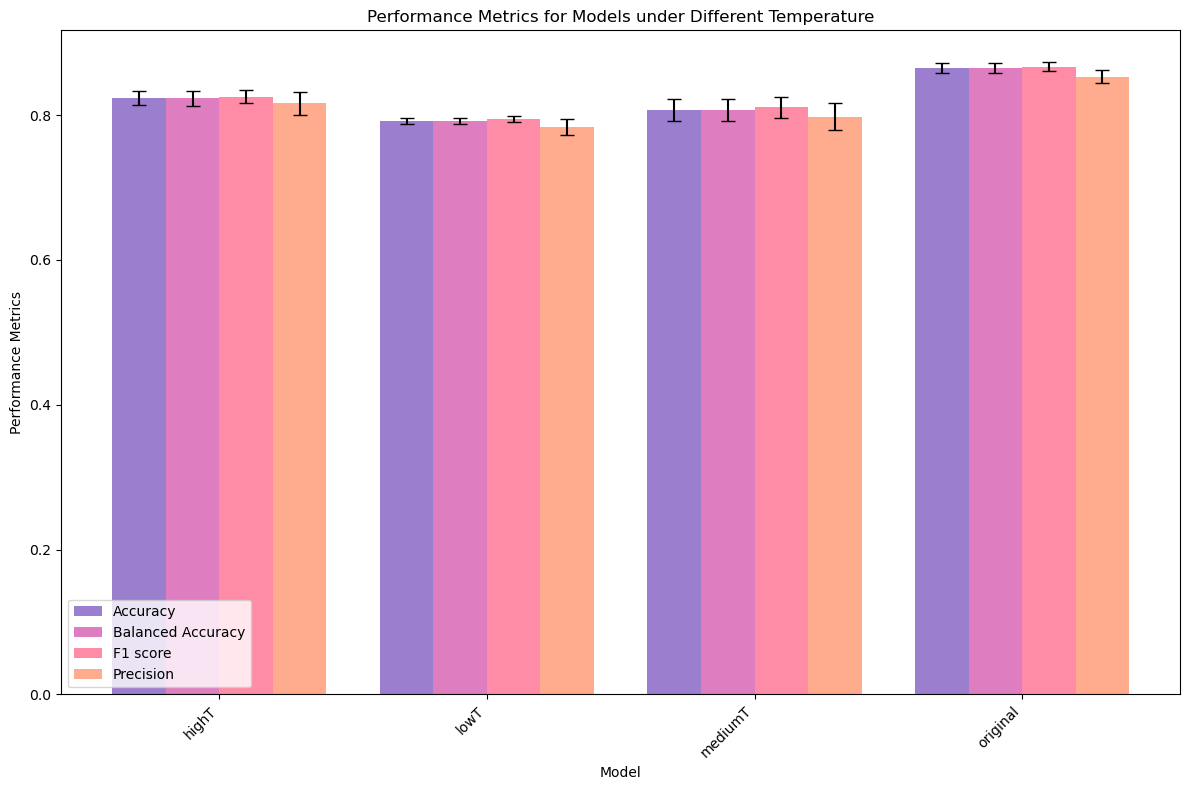

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Read CSV file
file_path = './temperature_analysis/performance.csv'
df = pd.read_csv(file_path)

# Set figure size
plt.figure(figsize=(12, 8))

# Define bar width
bar_width = 0.2
index = range(len(df))

colors = {
    'accuracy': '#845ec2',
    'precision': '#d65db1',
    'f1': '#ff6f91',
    'Precision': '#ff9671'
}

# Plot bar charts with error bars
plt.bar(index, df['accuracy_mean'], bar_width, yerr=df['accuracy_std'], capsize=5, label='Accuracy', alpha=0.8, color=colors['accuracy'])
plt.bar([i + bar_width for i in index], df['balanced_accuracy_mean'], bar_width, yerr=df['balanced_accuracy_std'], capsize=5, label='Balanced Accuracy', alpha=0.8, color=colors['precision'])
plt.bar([i + 2*bar_width for i in index], df['f1_mean'], bar_width, yerr=df['f1_std'], capsize=5, label='F1 score', alpha=0.8, color=colors['f1'])
plt.bar([i + 3*bar_width for i in index], df['precision_mean'], bar_width, yerr=df['precision_std'], capsize=5, label='Precision', alpha=0.8, color=colors['Precision'])

# Add legend and labels
plt.xlabel('Model')
plt.ylabel('Performance Metrics')
plt.title('Performance Metrics for Models under Different Temperature')
plt.xticks([i + 1.5*bar_width for i in index], df['folder'], rotation=45, ha='right')  # Rotate x-axis labels for better display
plt.legend()
plt.legend(loc='lower left')  # Place legend at the lower left

# Display the plot
plt.tight_layout()
plt.show()


In [10]:
model_path_1 = './temperature_analysis/original/autogluon_model_fold_1_original'

predictor.load(model_path_1)

predictor.feature_importance(data)

These features in provided data are not utilized by the predictor and will be ignored: ['bit_0', 'bit_1', 'bit_2', 'bit_3', 'bit_4', 'bit_5', 'bit_6', 'bit_7', 'bit_9', 'bit_10', 'bit_12', 'bit_27', 'bit_35', 'bit_40', 'bit_44', 'bit_143', 'bit_166']
Computing feature importance via permutation shuffling for 150 features using 5000 rows with 5 shuffle sets...
	343.36s	= Expected runtime (68.67s per shuffle set)
	126.77s	= Actual runtime (Completed 5 of 5 shuffle sets)


,importance,stddev,p_value,n,p99_high,p99_low
bit_49,0.02364,0.002439,0.000013,5,0.028662,0.018618
bit_161,0.00836,0.001862,0.000277,5,0.012194,0.004526
bit_123,0.00584,0.001033,0.000113,5,0.007968,0.003712
bit_164,0.00380,0.001114,0.000792,5,0.006093,0.001507
bit_159,0.00380,0.002232,0.009489,5,0.008395,-0.000795
...,...,...,...,...,...,...
bit_30,-0.00040,0.000283,0.982945,5,0.000182,-0.000982
bit_60,-0.00072,0.000110,0.999938,5,-0.000494,-0.000946
bit_55,-0.00076,0.000167,0.999735,5,-0.000415,-0.001105
bit_51,-0.00080,0.000424,0.993242,5,0.000074,-0.001674


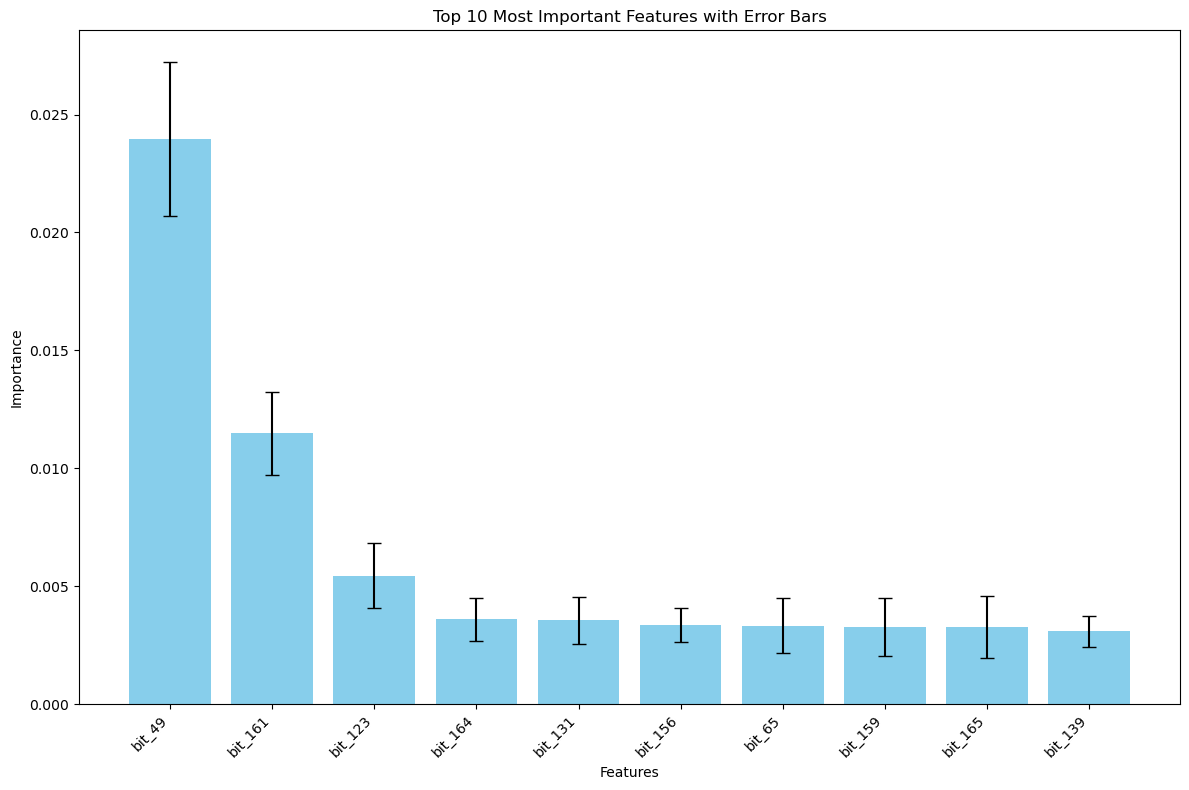

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load feature importance data
feature_importance_path = './feature_importance_formation_prediction.csv'
feature_importance_df = pd.read_csv(feature_importance_path)

# Ensure data is sorted in descending order of importance
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Select top 10 most important features
top_10_features = feature_importance_df.head(10)

# Extract feature names, importance values and standard deviations
features = top_10_features['feature']
importances = top_10_features['importance']
stddevs = top_10_features['stddev']  # Assuming the standard deviation column is named 'stddev'

# Plot bar chart with standard deviations as error bars
plt.figure(figsize=(12, 8))
plt.bar(features, importances, yerr=stddevs, color='skyblue', capsize=5)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Top 10 Most Important Features with Error Bars')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save the chart
plt.savefig('./top_10_features_with_error_bars.png')
plt.show()
    

In [24]:
model_path_1 = './temperature_analysis/original/autogluon_model_fold_1_original'

predictor.load(model_path_1)
predictor.evaluate(data)

{'accuracy': 0.9599214145383104,
 'balanced_accuracy': 0.9599214145383104,
 'mcc': 0.9199155500216394,
 'roc_auc': 0.9915240986409655,
 'f1': 0.960171807887544,
 'precision': 0.954210322079938,
 'recall': 0.9662082514734774}

PermutationExplainer explainer: 10181it [58:02,  2.92it/s]                            
C:\Users\15710\AppData\Local\Temp\ipykernel_170100\368890329.py:26: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, data)


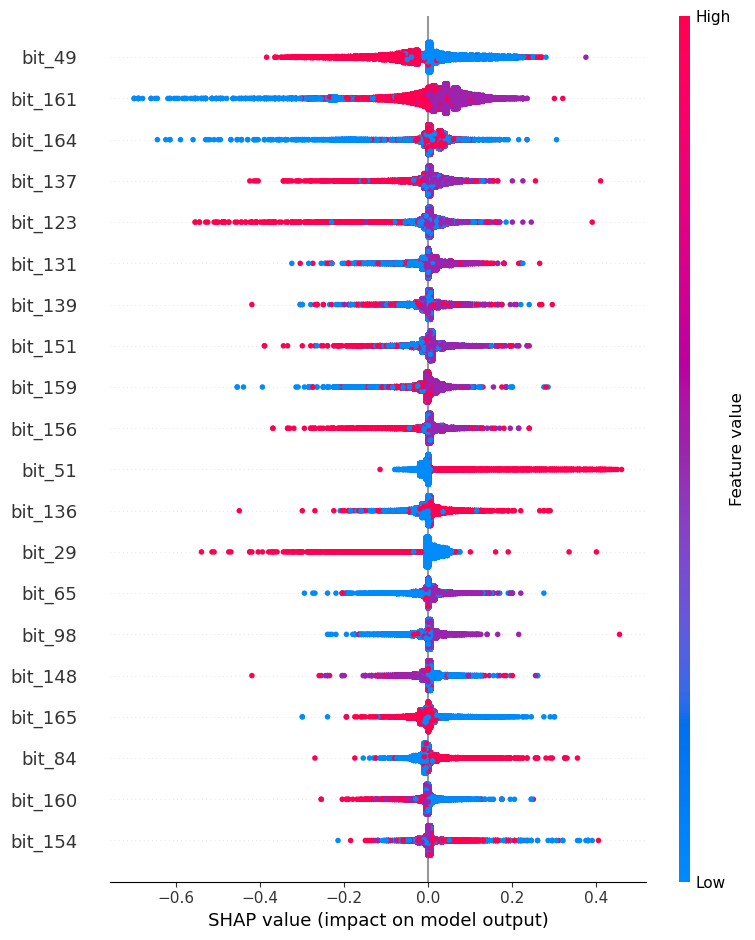

In [27]:
import pandas as pd
import numpy as np
import shap
from autogluon.tabular import TabularPredictor

# Load data
data_path = './temperature_analysis/original/training_dataset.csv'
data = pd.read_csv(data_path)

# Remove unnecessary columns
data = data.drop(columns=['coformer1', 'coformer2', 'refcode'])

# Ensure all columns are numeric
data = data.select_dtypes(include=[np.number])

# Load model
model_path = './temperature_analysis/original/autogluon_model_fold_1_original'
predictor = TabularPredictor.load(model_path)

# Create SHAP Explainer
explainer = shap.Explainer(predictor.predict, data)

# Calculate SHAP values
shap_values = explainer(data)

# Plot SHAP summary plot
shap.summary_plot(shap_values, data)
    

C:\Users\15710\AppData\Local\Temp\ipykernel_170100\2095183704.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, data,cmap='copper_r',max_display=10,plot_type='bar')


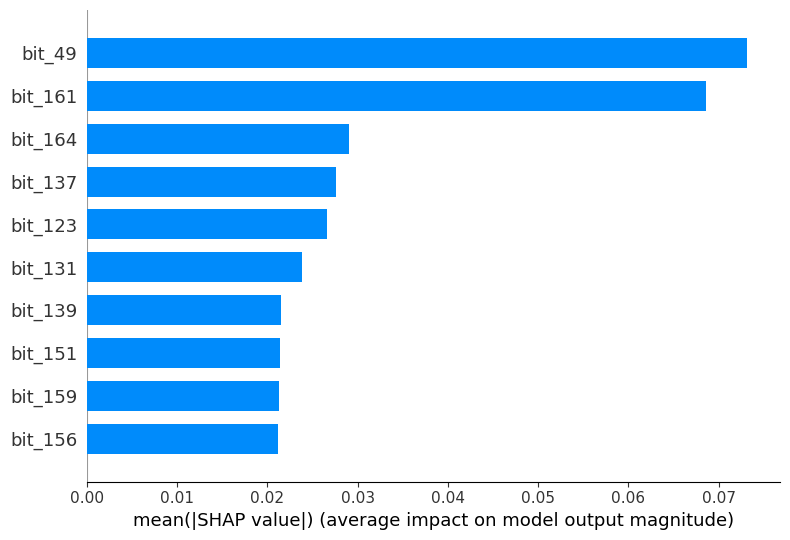

In [29]:
shap.summary_plot(shap_values, data,cmap='copper_r',max_display=10,plot_type='bar')

In [6]:
import pandas as pd
from autogluon.tabular import TabularPredictor
import os

# Define model paths
model_paths = [
'./temperature_analysis/original/autogluon_model_fold_1_original',
'./temperature_analysis/original/autogluon_model_fold_2_original',
'./temperature_analysis/original/autogluon_model_fold_3_original',
'./temperature_analysis/original/autogluon_model_fold_4_original',
'./temperature_analysis/original/autogluon_model_fold_5_original'
]

# Load prediction data (keep original data for later merging)
predictions_file = './predictions/pcc_predictions.csv'
original_data = pd.read_csv(predictions_file)  # Save original data
data = original_data.copy()  # Create a copy for processing

# Convert maccs column to feature columns from bit_0 to bit_n
def convert_maccs_to_bits(maccs):
    bits = [int(bit) for bit in maccs]
    return pd.Series(bits, index=[f"bit_{i}" for i in range(len(bits))])

# Apply the conversion
data = pd.concat([data.drop(columns=['maccs']), data['maccs'].apply(convert_maccs_to_bits)], axis=1)

# Load models and make predictions
predictions = []
probabilities = []
for model_path in model_paths:
    predictor = TabularPredictor.load(model_path)
    prediction = predictor.predict(data)
    
    # Get prediction probabilities
    proba_df = predictor.predict_proba(data)
    
    # Check column names to determine the correct probability column
    if 1 in proba_df.columns:
        probability = proba_df[1]
    elif '1' in proba_df.columns:
        probability = proba_df['1']
    elif 'class_1' in proba_df.columns:
        probability = proba_df['class_1']
    else:
        raise ValueError(f"Could not find the column for class 1 in the probability DataFrame. Columns found: {proba_df.columns}")
    
    predictions.append(prediction)
    probabilities.append(probability)

# Calculate average prediction value
average_prediction = pd.concat(predictions, axis=1).mean(axis=1)

# Calculate mean and variance of probabilities for output 1
average_probability = pd.concat(probabilities, axis=1).mean(axis=1)
variance_probability = pd.concat(probabilities, axis=1).var(axis=1)

# Create results DataFrame, merging with original data
results = pd.concat([
    original_data.reset_index(drop=True),  # Original data
    pd.DataFrame({
        'average_prediction': average_prediction,
        'average_probability': average_probability,
        'variance_probability': variance_probability
    })
], axis=1)

# Save results to CSV file
output_folder = './predictions'
output_file = os.path.join(output_folder, 'prediction_results_with_original_data.csv')
results.to_csv(output_file, index=False)

print(f"Results with original data saved to {output_file}")
    

Results with original data saved to F:\project\cocrystal\git_0714\Section1\Cocrystal Prediction by machine learning\autogluon_version\predictions\prediction_results_with_original_data.csv
